# Temperature Scaling — Post-Hoc Calibration

**Goal:** Apply temperature scaling to both KanResWideX and CNN-BiLSTM to reduce overconfidence without retraining.

Temperature scaling learns a single parameter T that softens the model's predictions:
- Original: `softmax(logits)`
- Scaled: `softmax(logits / T)`

When T > 1, predictions become less extreme (less overconfident).  
Classification accuracy is unchanged — only the confidence scores change.

### Evaluated on:
1. Chapman-Shaoxing (validation set from best fold)
2. PTB-XL (cross-dataset)
3. Georgia (cross-dataset)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb -q
print('Drive mounted.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 159.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
Drive mounted.


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""

    kanres_model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth"
    bilstm_model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_cnn_bilstm_12lead.pth"

    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds

    batch_size = 128
    num_classes = 2
    n_folds = 5
    random_seed = 42

    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_temperature_scaling"

config = Config()
assert os.path.exists(config.kanres_model_path), f"KanResWideX model not found"
assert os.path.exists(config.bilstm_model_path), f"CNN-BiLSTM model not found"
os.makedirs(config.pdf_dir, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Unzip Chapman-Shaoxing Data

In [4]:
import os

if not os.path.exists("/content/subset_data"):
    print("Unzipping Chapman-Shaoxing subset...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset_ecg_arrhythmia.zip" -d /content/subset_data/
    print("Done!")

for base in ["/content/subset_data",
             "/content/subset_data/afib_normal_subset",
             "/content/subset_data/afib_normal_subset_ecg_arrhythmia"]:
    afib_path = os.path.join(base, "afib")
    normal_path = os.path.join(base, "normal")
    if os.path.exists(afib_path) and os.path.exists(normal_path):
        config.afib_dir = afib_path
        config.normal_dir = normal_path
        break

print(f"AFib: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])} records")
print(f"Normal: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])} records")

Unzipping Chapman-Shaoxing subset...
Done!
AFib: 1780 records
Normal: 8125 records


## 4. Model Definitions

In [5]:
# KanResWideX
class KanResInit(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride)
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2)
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()
    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        return x

class KanResModule(nn.Module):
    def __init__(self, in_channels, filterno_1, filterno_2, filtersize_1, filtersize_2, stride):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, filterno_1, filtersize_1, stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(filterno_1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(filterno_1, filterno_2, filtersize_2, padding='same')
        self.bn2 = nn.BatchNorm1d(filterno_2)
        self.relu2 = nn.ReLU()
    def forward(self, x):
        identity = x
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.conv2(out)))
        return out + identity

class KanResWideX(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(kernel_size=2)
        self.res_modules = nn.ModuleList([KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)
    def forward(self, x):
        x = self.init_block(x)
        x = self.pool(x)
        for m in self.res_modules:
            x = m(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x

# CNN-BiLSTM
class CNNBiLSTM(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.cnn1 = nn.Sequential(nn.Conv1d(input_channels, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(3), nn.Dropout(0.2))
        self.cnn2 = nn.Sequential(nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.cnn3 = nn.Sequential(nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3))
        self.bilstm1 = nn.LSTM(256, 128, batch_first=True, bidirectional=True)
        self.dropout_lstm1 = nn.Dropout(0.3)
        self.bilstm2 = nn.LSTM(256, 64, batch_first=True, bidirectional=True)
        self.dropout_lstm2 = nn.Dropout(0.3)
        self.classifier = nn.Sequential(nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, output_size))
    def forward(self, x):
        x = self.cnn1(x); x = self.cnn2(x); x = self.cnn3(x)
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm1(x); x = self.dropout_lstm1(x)
        x, _ = self.bilstm2(x); x = self.dropout_lstm2(x)
        x = x[:, -1, :]
        x = self.classifier(x)
        return x

print("Both models defined.")

Both models defined.


## 5. Load Records & Helper Functions

In [6]:
def load_record(record_info, config):
    try:
        rec = wfdb.rdrecord(record_info["path"])
        signal = rec.p_signal
    except:
        return None, None
    if signal.shape[1] < config.num_channels or np.any(np.isnan(signal)):
        return None, None
    if len(signal) < config.recording_samples:
        signal = np.vstack([signal, np.zeros((config.recording_samples - len(signal), config.num_channels))])
    elif len(signal) > config.recording_samples:
        signal = signal[:config.recording_samples, :]
    for ch in range(config.num_channels):
        std = np.std(signal[:, ch])
        if std < 1e-6:
            signal[:, ch] = np.random.normal(0, 1e-4, len(signal[:, ch]))
        else:
            signal[:, ch] = (signal[:, ch] - np.mean(signal[:, ch])) / std
    return signal[:, :config.num_channels].T.copy().astype(np.float32), np.int64(record_info["label"])

class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, samples, labels):
        self.samples = torch.FloatTensor(samples)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

def get_logits_and_labels(model, dataloader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            logits = model(inputs)
            all_logits.append(logits.cpu())
            all_labels.append(targets)
    return torch.cat(all_logits), torch.cat(all_labels)

def compute_calibration_metrics(targets, probs):
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i + 1])
        else:
            mask = (probs >= bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        bin_count = mask.sum()
        if bin_count > 0:
            cal_error = abs(targets[mask].mean() - probs[mask].mean())
            ece += (bin_count / len(targets)) * cal_error
            mce = max(mce, cal_error)
    return {"ece": ece, "mce": mce, "brier": brier}

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    cal = compute_calibration_metrics(targets, probs)
    return {
        "accuracy": accuracy_score(targets, preds),
        "precision": precision_score(targets, preds, pos_label=1, zero_division=0),
        "recall": recall_score(targets, preds, pos_label=1, zero_division=0),
        "f1": f1_score(targets, preds, pos_label=1, zero_division=0),
        "mcc": matthews_corrcoef(targets, preds),
        "auroc": roc_auc_score(targets, probs),
        "auprc": average_precision_score(targets, probs),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        **cal, "cm": cm
    }

print("Functions defined.")

Functions defined.


## 6. Load Chapman-Shaoxing Data

In [7]:
# Discover records
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

# Load all records
print(f"Loading {len(all_records)} records...")
start_time = time.time()
patient_data = {}
skipped = 0
for i, rec in enumerate(all_records):
    if (i + 1) % 2000 == 0:
        print(f"  Processed {i+1}/{len(all_records)} ({time.time()-start_time:.0f}s)...")
    sample, label = load_record(rec, config)
    if sample is not None:
        patient_data[rec["name"]] = {"sample": sample, "label": label}
    else:
        skipped += 1

print(f"Loaded: {len(patient_data)} (skipped: {skipped})")
afib_p = sum(1 for p in patient_data.values() if p["label"] == 1)
normal_p = sum(1 for p in patient_data.values() if p["label"] == 0)
print(f"  AFib: {afib_p}, Normal: {normal_p}")

Loading 9905 records...
  Processed 2000/9905 (20s)...
  Processed 4000/9905 (40s)...
  Processed 6000/9905 (60s)...
  Processed 8000/9905 (79s)...
Loaded: 9889 (skipped: 16)
  AFib: 1780, Normal: 8109


## 7. Recreate Same 5-Fold Split

In [8]:
np.random.seed(config.random_seed)
patient_names = np.array(sorted(patient_data.keys()))
patient_labels = np.array([patient_data[p]["label"] for p in patient_names])

skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)
folds = []
for train_idx, val_idx in skf.split(patient_names, patient_labels):
    folds.append({
        "train": patient_names[train_idx].tolist(),
        "val": patient_names[val_idx].tolist()
    })

def merge_patients(patient_list):
    s = np.array([patient_data[p]["sample"] for p in patient_list], dtype=np.float32)
    l = np.array([patient_data[p]["label"] for p in patient_list], dtype=np.int64)
    return s, l

print(f"5-fold split recreated (seed={config.random_seed})")
for i, fold in enumerate(folds):
    val_afib = sum(1 for p in fold["val"] if patient_data[p]["label"] == 1)
    print(f"  Fold {i+1}: val={len(fold['val'])} (AFib={val_afib})")

5-fold split recreated (seed=42)
  Fold 1: val=1978 (AFib=356)
  Fold 2: val=1978 (AFib=356)
  Fold 3: val=1978 (AFib=356)
  Fold 4: val=1978 (AFib=356)
  Fold 5: val=1977 (AFib=356)


## 8. Temperature Scaling Implementation

Temperature scaling learns a single parameter T by minimizing the negative log-likelihood (NLL) on the validation logits. The optimal T softens overconfident predictions without changing the classification decisions.

In [9]:
def find_optimal_temperature(logits, labels):
    """Find optimal temperature T that minimizes NLL on the given logits/labels."""
    def nll_with_temperature(T):
        scaled_logits = logits / T
        log_probs = torch.nn.functional.log_softmax(scaled_logits, dim=1)
        nll = torch.nn.functional.nll_loss(log_probs, labels)
        return nll.item()

    # Search for optimal T in range [0.1, 10]
    result = minimize_scalar(nll_with_temperature, bounds=(0.1, 10.0), method='bounded')
    return result.x

def apply_temperature(logits, T):
    """Apply temperature scaling to logits and return calibrated probabilities."""
    scaled_logits = logits / T
    probs = torch.softmax(scaled_logits, dim=1)[:, 1].numpy()
    return probs

print("Temperature scaling functions defined.")

Temperature scaling functions defined.


## 9. Run Temperature Scaling on Chapman-Shaoxing (All 5 Folds)

In [10]:
results = {}

for model_name, model_path, ModelClass in [
    ("KanResWideX", config.kanres_model_path, KanResWideX),
    ("CNN-BiLSTM", config.bilstm_model_path, CNNBiLSTM)
]:
    print(f"\n{'='*70}")
    print(f"TEMPERATURE SCALING: {model_name}")
    print(f"{'='*70}")

    # Load model
    model = ModelClass(input_channels=config.num_channels, output_size=config.num_classes).to(device)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Model loaded: {model_path}")

    fold_results_before = []
    fold_results_after = []
    fold_temperatures = []
    fold_probs_before = []
    fold_probs_after = []
    fold_targets_all = []

    for fold_idx, fold in enumerate(folds):
        X_val, y_val = merge_patients(fold["val"])
        val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)

        # Get logits
        logits, labels = get_logits_and_labels(model, val_loader, device)

        # Before temperature scaling
        probs_before = torch.softmax(logits, dim=1)[:, 1].numpy()
        preds_before = (probs_before >= 0.5).astype(int)
        targets = labels.numpy()
        metrics_before = compute_all_metrics(targets, preds_before, probs_before)

        # Find optimal temperature
        T = find_optimal_temperature(logits, labels)

        # After temperature scaling
        probs_after = apply_temperature(logits, T)
        preds_after = (probs_after >= 0.5).astype(int)
        metrics_after = compute_all_metrics(targets, preds_after, probs_after)

        fold_results_before.append(metrics_before)
        fold_results_after.append(metrics_after)
        fold_temperatures.append(T)
        fold_probs_before.append(probs_before)
        fold_probs_after.append(probs_after)
        fold_targets_all.append(targets)

        print(f"  Fold {fold_idx+1}: T={T:.4f} | ECE: {metrics_before['ece']:.4f} -> {metrics_after['ece']:.4f} | MCE: {metrics_before['mce']:.4f} -> {metrics_after['mce']:.4f}")

    mean_T = np.mean(fold_temperatures)
    print(f"\n  Mean temperature: {mean_T:.4f}")

    results[model_name] = {
        "before": fold_results_before,
        "after": fold_results_after,
        "temperatures": fold_temperatures,
        "mean_T": mean_T,
        "probs_before": fold_probs_before,
        "probs_after": fold_probs_after,
        "targets": fold_targets_all
    }


TEMPERATURE SCALING: KanResWideX
Model loaded: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth
  Fold 1: T=0.1786 | ECE: 0.0001 -> 0.0000 | MCE: 0.0003 -> 0.0000
  Fold 2: T=0.1786 | ECE: 0.0002 -> 0.0000 | MCE: 0.0003 -> 0.0000
  Fold 3: T=1.0271 | ECE: 0.0022 -> 0.0022 | MCE: 0.5736 -> 0.5717
  Fold 4: T=0.2186 | ECE: 0.0001 -> 0.0000 | MCE: 0.0003 -> 0.0000
  Fold 5: T=0.1521 | ECE: 0.0002 -> 0.0000 | MCE: 0.0004 -> 0.0000

  Mean temperature: 0.3510

TEMPERATURE SCALING: CNN-BiLSTM
Model loaded: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_cnn_bilstm_12lead.pth
  Fold 1: T=1.3110 | ECE: 0.0030 -> 0.0031 | MCE: 0.8657 -> 0.8502
  Fold 2: T=1.4630 | ECE: 0.0048 -> 0.0048 | MCE: 0.8806 -> 0.7967
  Fold 3: T=0.6182 | ECE: 0.0014 -> 0.0009 | MCE: 0.6314 -> 0.7415
  Fold 4: T=1.4716 | ECE: 0.0051 -> 0.0039 | MCE: 0.6648 -> 0.5160
  Fold 5: T=1.0672 | ECE: 0.0010 -> 0.0009 | MCE: 0.3323 -> 0.3420

  Mean temperat

## 10. Chapman-Shaoxing: Before vs After Comparison

In [11]:
print("=" * 90)
print("TEMPERATURE SCALING RESULTS — Chapman-Shaoxing (5-Fold CV)")
print("=" * 90)

for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = results[model_name]
    print(f"\n--- {model_name} (Mean T = {r['mean_T']:.4f}) ---")
    print(f"{'Metric':<15} {'Before':<20} {'After':<20} {'Change':<15}")
    print("-" * 70)

    for metric in ["accuracy", "f1", "auroc", "brier", "ece", "mce"]:
        before = np.mean([m[metric] for m in r["before"]])
        after = np.mean([m[metric] for m in r["after"]])
        change = after - before
        arrow = "improved" if (metric in ["brier", "ece", "mce"] and change < 0) or (metric not in ["brier", "ece", "mce"] and change > 0) else "degraded" if change != 0 else "unchanged"
        print(f"{metric.upper():<15} {before:<20.4f} {after:<20.4f} {change:+.4f} ({arrow})")

TEMPERATURE SCALING RESULTS — Chapman-Shaoxing (5-Fold CV)

--- KanResWideX (Mean T = 0.3510) ---
Metric          Before               After                Change         
----------------------------------------------------------------------
ACCURACY        0.9995               0.9995               +0.0000 (unchanged)
F1              0.9986               0.9986               +0.0000 (unchanged)
AUROC           1.0000               1.0000               +0.0000 (unchanged)
BRIER           0.0004               0.0004               -0.0000 (improved)
ECE             0.0006               0.0004               -0.0001 (improved)
MCE             0.1150               0.1143               -0.0006 (improved)

--- CNN-BiLSTM (Mean T = 1.1862) ---
Metric          Before               After                Change         
----------------------------------------------------------------------
ACCURACY        0.9971               0.9971               +0.0000 (unchanged)
F1              0.9919         

## 11. Calibration Plots: Before vs After

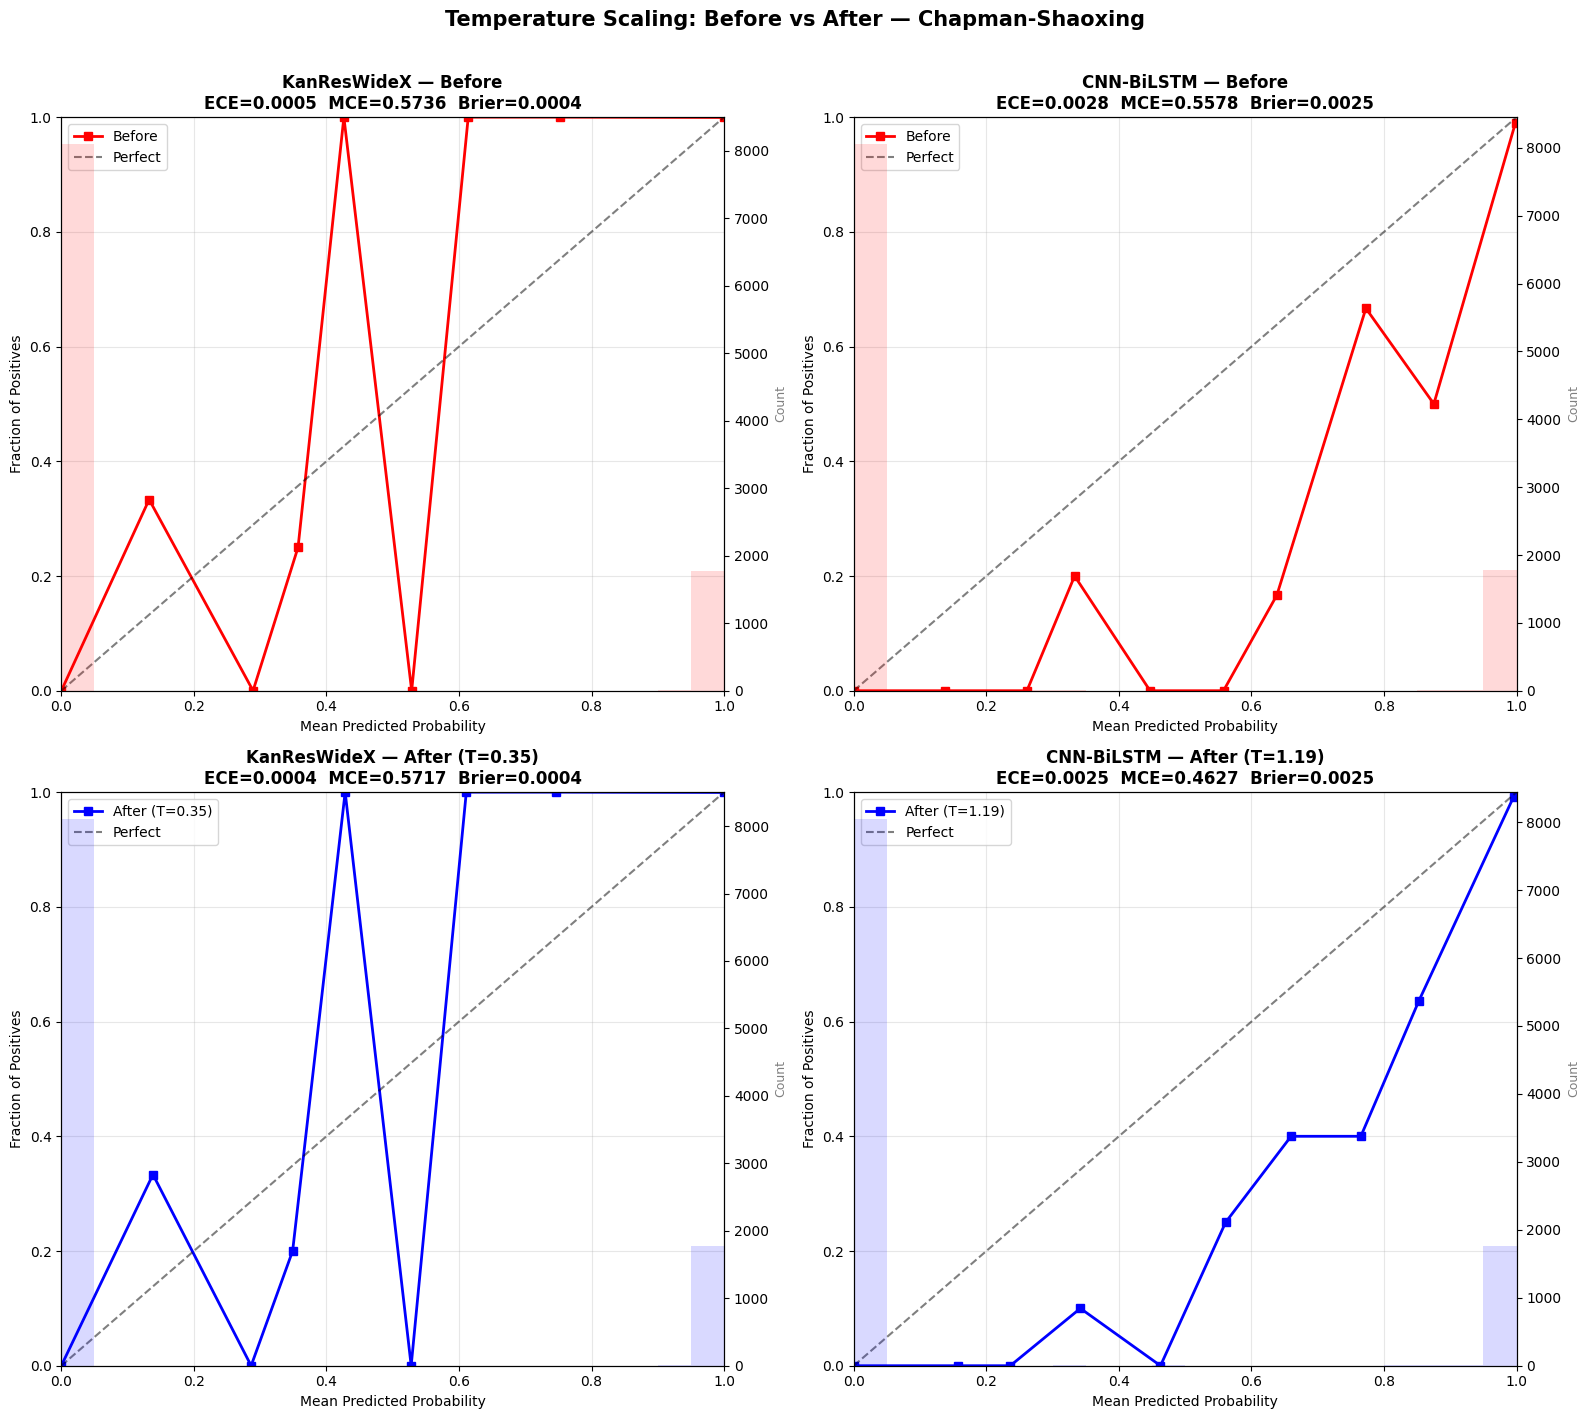

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, model_name in enumerate(["KanResWideX", "CNN-BiLSTM"]):
    r = results[model_name]
    all_targets = np.concatenate(r["targets"])
    all_probs_before = np.concatenate(r["probs_before"])
    all_probs_after = np.concatenate(r["probs_after"])

    # Before
    ax = axes[0][col]
    frac, mean_pred = calibration_curve(all_targets, all_probs_before, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac, 's-', color='red', linewidth=2, markersize=6, label='Before')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_probs_before, bins=20, range=(0, 1), alpha=0.15, color='red')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    before_cal = compute_calibration_metrics(all_targets, all_probs_before)
    ax.set_title(f"{model_name} — Before\nECE={before_cal['ece']:.4f}  MCE={before_cal['mce']:.4f}  Brier={before_cal['brier']:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left'); ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)

    # After
    ax = axes[1][col]
    frac, mean_pred = calibration_curve(all_targets, all_probs_after, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac, 's-', color='blue', linewidth=2, markersize=6, label=f'After (T={r["mean_T"]:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_probs_after, bins=20, range=(0, 1), alpha=0.15, color='blue')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    after_cal = compute_calibration_metrics(all_targets, all_probs_after)
    ax.set_title(f"{model_name} — After (T={r['mean_T']:.2f})\nECE={after_cal['ece']:.4f}  MCE={after_cal['mce']:.4f}  Brier={after_cal['brier']:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left'); ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)

plt.suptitle("Temperature Scaling: Before vs After — Chapman-Shaoxing", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_calibration_before_after_chapman.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 12. Probability Distributions: Before vs After

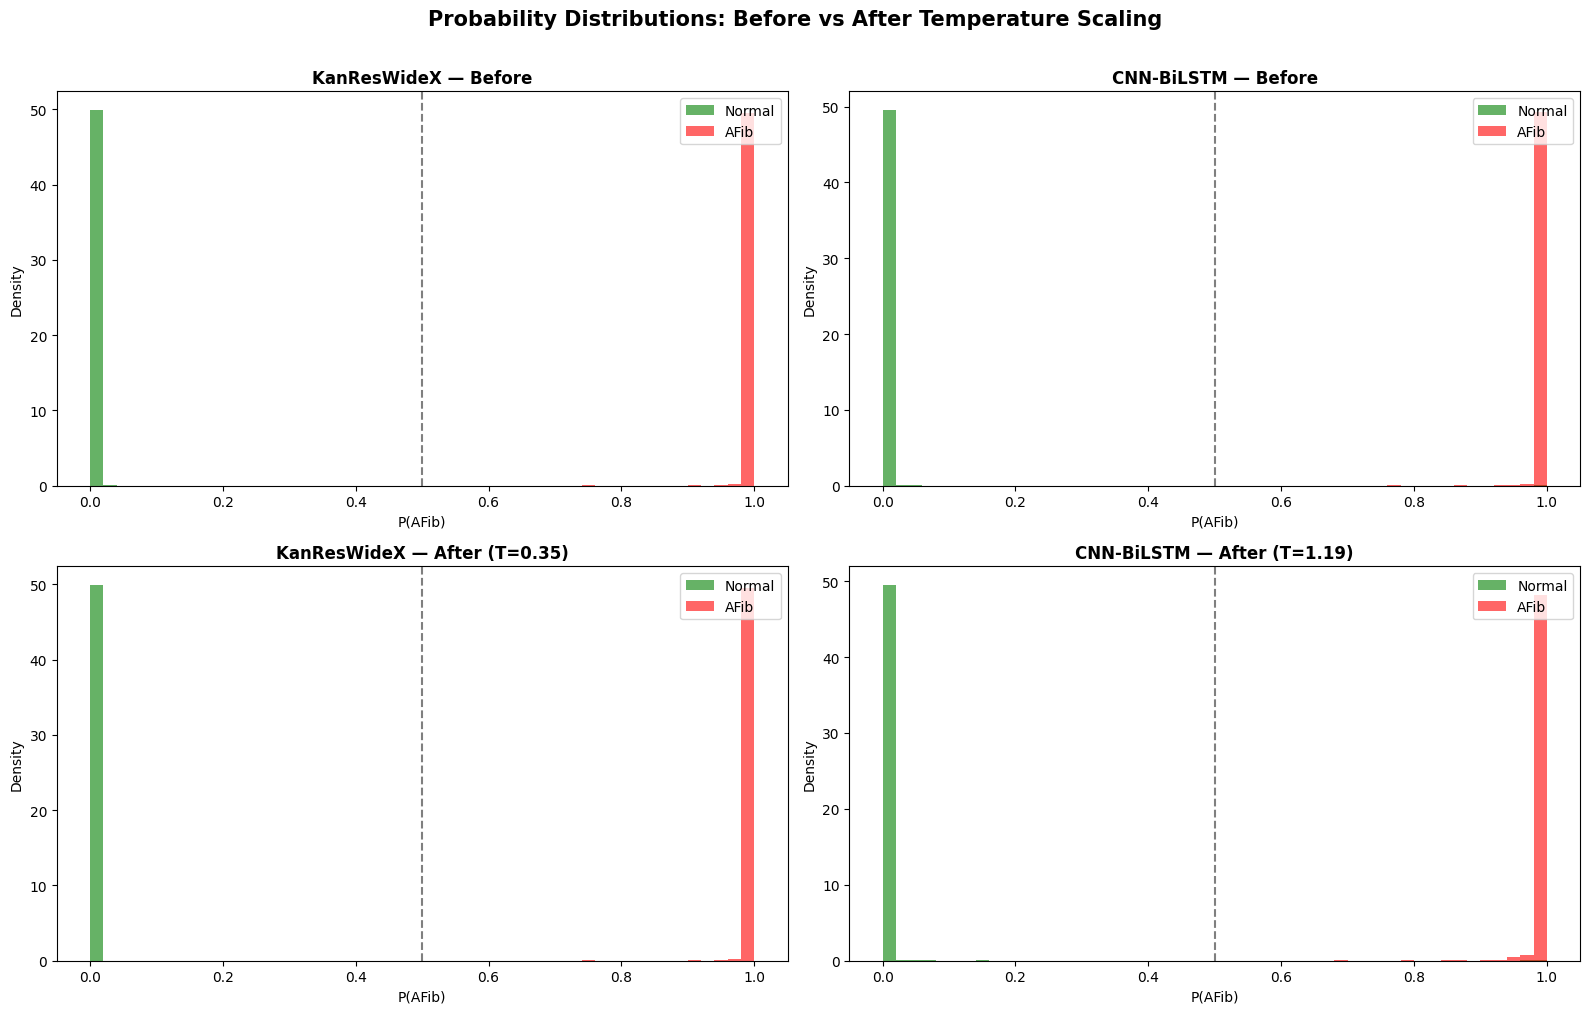

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, model_name in enumerate(["KanResWideX", "CNN-BiLSTM"]):
    r = results[model_name]
    all_targets = np.concatenate(r["targets"])
    all_probs_before = np.concatenate(r["probs_before"])
    all_probs_after = np.concatenate(r["probs_after"])

    for row, (probs, label) in enumerate([(all_probs_before, "Before"), (all_probs_after, f"After (T={r['mean_T']:.2f})")]):
        ax = axes[row][col]
        mask_neg = all_targets == 0
        mask_pos = all_targets == 1
        ax.hist(probs[mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Normal', density=True)
        ax.hist(probs[mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
        ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
        ax.set_title(f"{model_name} — {label}", fontsize=12, fontweight='bold')
        ax.set_xlabel("P(AFib)"); ax.set_ylabel("Density")
        ax.legend()

plt.suptitle("Probability Distributions: Before vs After Temperature Scaling", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_prob_dist_before_after_chapman.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
# Fix Georgia .hea files (timestamp format incompatible with wfdb)
fixed = 0
for folder in [georgia_afib, georgia_normal]:
    if not folder:
        continue
    for fname in os.listdir(folder):
        if fname.endswith('.hea'):
            fpath = os.path.join(folder, fname)
            with open(fpath, 'r') as f:
                lines = f.readlines()
            first_line = lines[0].strip().split()
            record_name = first_line[0].replace('.mat', '')
            lines[0] = f"{record_name} {first_line[1]} {first_line[2]} {first_line[3]}\n"
            with open(fpath, 'w') as f:
                f.writelines(lines)
            fixed += 1
print(f"Fixed {fixed} Georgia .hea files")

Fixed 2322 Georgia .hea files


## 13. Cross-Dataset Validation with Temperature Scaling

Apply the mean temperature learned on Chapman-Shaoxing to PTB-XL and Georgia.

In [16]:
def load_cross_dataset(afib_dir, normal_dir, config, dataset_name):
    afib_files = sorted([f[:-4] for f in os.listdir(afib_dir) if f.endswith('.hea')])
    normal_files = sorted([f[:-4] for f in os.listdir(normal_dir) if f.endswith('.hea')])

    records = []
    for name in afib_files:
        records.append({"path": os.path.join(afib_dir, name), "name": name, "label": 1})
    for name in normal_files:
        records.append({"path": os.path.join(normal_dir, name), "name": name, "label": 0})

    samples, labels = [], []
    skipped = 0
    for rec in records:
        s, l = load_record(rec, config)
        if s is not None:
            samples.append(s)
            labels.append(l)
        else:
            skipped += 1

    samples = np.array(samples, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    afib_n = np.sum(labels == 1)
    print(f"{dataset_name}: {len(labels)} loaded (AFib={afib_n}, Normal={len(labels)-afib_n}, skipped={skipped})")
    return samples, labels

# Unzip PTB-XL
if not os.path.exists("/content/ptbxl_data"):
    print("Unzipping PTB-XL...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/ptbxl_afib_normal_subset.zip" -d /content/ptbxl_data/
ptbxl_afib, ptbxl_normal = "", ""
for base in ["/content/ptbxl_data", "/content/ptbxl_data/ptbxl_afib_normal_subset"]:
    if os.path.exists(os.path.join(base, "afib")):
        ptbxl_afib = os.path.join(base, "afib")
        ptbxl_normal = os.path.join(base, "normal")
        break

# Unzip Georgia
if not os.path.exists("/content/georgia_data"):
    print("Unzipping Georgia...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/georgia_afib_normal_subset.zip" -d /content/georgia_data/
georgia_afib, georgia_normal = "", ""
for base in ["/content/georgia_data", "/content/georgia_data/georgia_afib_normal_subset"]:
    if os.path.exists(os.path.join(base, "afib")):
        georgia_afib = os.path.join(base, "afib")
        georgia_normal = os.path.join(base, "normal")
        break

X_ptbxl, y_ptbxl = load_cross_dataset(ptbxl_afib, ptbxl_normal, config, "PTB-XL")
X_georgia, y_georgia = load_cross_dataset(georgia_afib, georgia_normal, config, "Georgia")

PTB-XL: 10954 loaded (AFib=1477, Normal=9477, skipped=0)
Georgia: 2321 loaded (AFib=570, Normal=1751, skipped=1)


## 14. Cross-Dataset: Before vs After Temperature Scaling

In [17]:
cross_results = {}

for model_name, model_path, ModelClass in [
    ("KanResWideX", config.kanres_model_path, KanResWideX),
    ("CNN-BiLSTM", config.bilstm_model_path, CNNBiLSTM)
]:
    model = ModelClass(input_channels=config.num_channels, output_size=config.num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    T = results[model_name]["mean_T"]
    cross_results[model_name] = {}

    for ds_name, X, y in [("PTB-XL", X_ptbxl, y_ptbxl), ("Georgia", X_georgia, y_georgia)]:
        loader = DataLoader(ECGDataset(X, y), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
        logits, labels = get_logits_and_labels(model, loader, device)
        targets = labels.numpy()

        # Before
        probs_before = torch.softmax(logits, dim=1)[:, 1].numpy()
        preds_before = (probs_before >= 0.5).astype(int)
        metrics_before = compute_all_metrics(targets, preds_before, probs_before)

        # After
        probs_after = apply_temperature(logits, T)
        preds_after = (probs_after >= 0.5).astype(int)
        metrics_after = compute_all_metrics(targets, preds_after, probs_after)

        cross_results[model_name][ds_name] = {
            "before": metrics_before, "after": metrics_after,
            "probs_before": probs_before, "probs_after": probs_after,
            "targets": targets, "T": T
        }

        print(f"{model_name} on {ds_name} (T={T:.4f}):")
        print(f"  ECE: {metrics_before['ece']:.4f} -> {metrics_after['ece']:.4f}")
        print(f"  MCE: {metrics_before['mce']:.4f} -> {metrics_after['mce']:.4f}")
        print(f"  Brier: {metrics_before['brier']:.4f} -> {metrics_after['brier']:.4f}")
        print(f"  Acc: {metrics_before['accuracy']:.4f} -> {metrics_after['accuracy']:.4f}")
        print()

KanResWideX on PTB-XL (T=0.3510):
  ECE: 0.0063 -> 0.0088
  MCE: 0.2740 -> 0.4546
  Brier: 0.0080 -> 0.0088
  Acc: 0.9900 -> 0.9900

KanResWideX on Georgia (T=0.3510):
  ECE: 0.0464 -> 0.0472
  MCE: 0.8746 -> 0.8514
  Brier: 0.0446 -> 0.0463
  Acc: 0.9526 -> 0.9526

CNN-BiLSTM on PTB-XL (T=1.1862):
  ECE: 0.0069 -> 0.0064
  MCE: 0.1612 -> 0.1762
  Brier: 0.0084 -> 0.0084
  Acc: 0.9907 -> 0.9907

CNN-BiLSTM on Georgia (T=1.1862):
  ECE: 0.0489 -> 0.0472
  MCE: 0.5582 -> 0.7691
  Brier: 0.0496 -> 0.0487
  Acc: 0.9449 -> 0.9449



## 15. Cross-Dataset Calibration Plots: Before vs After

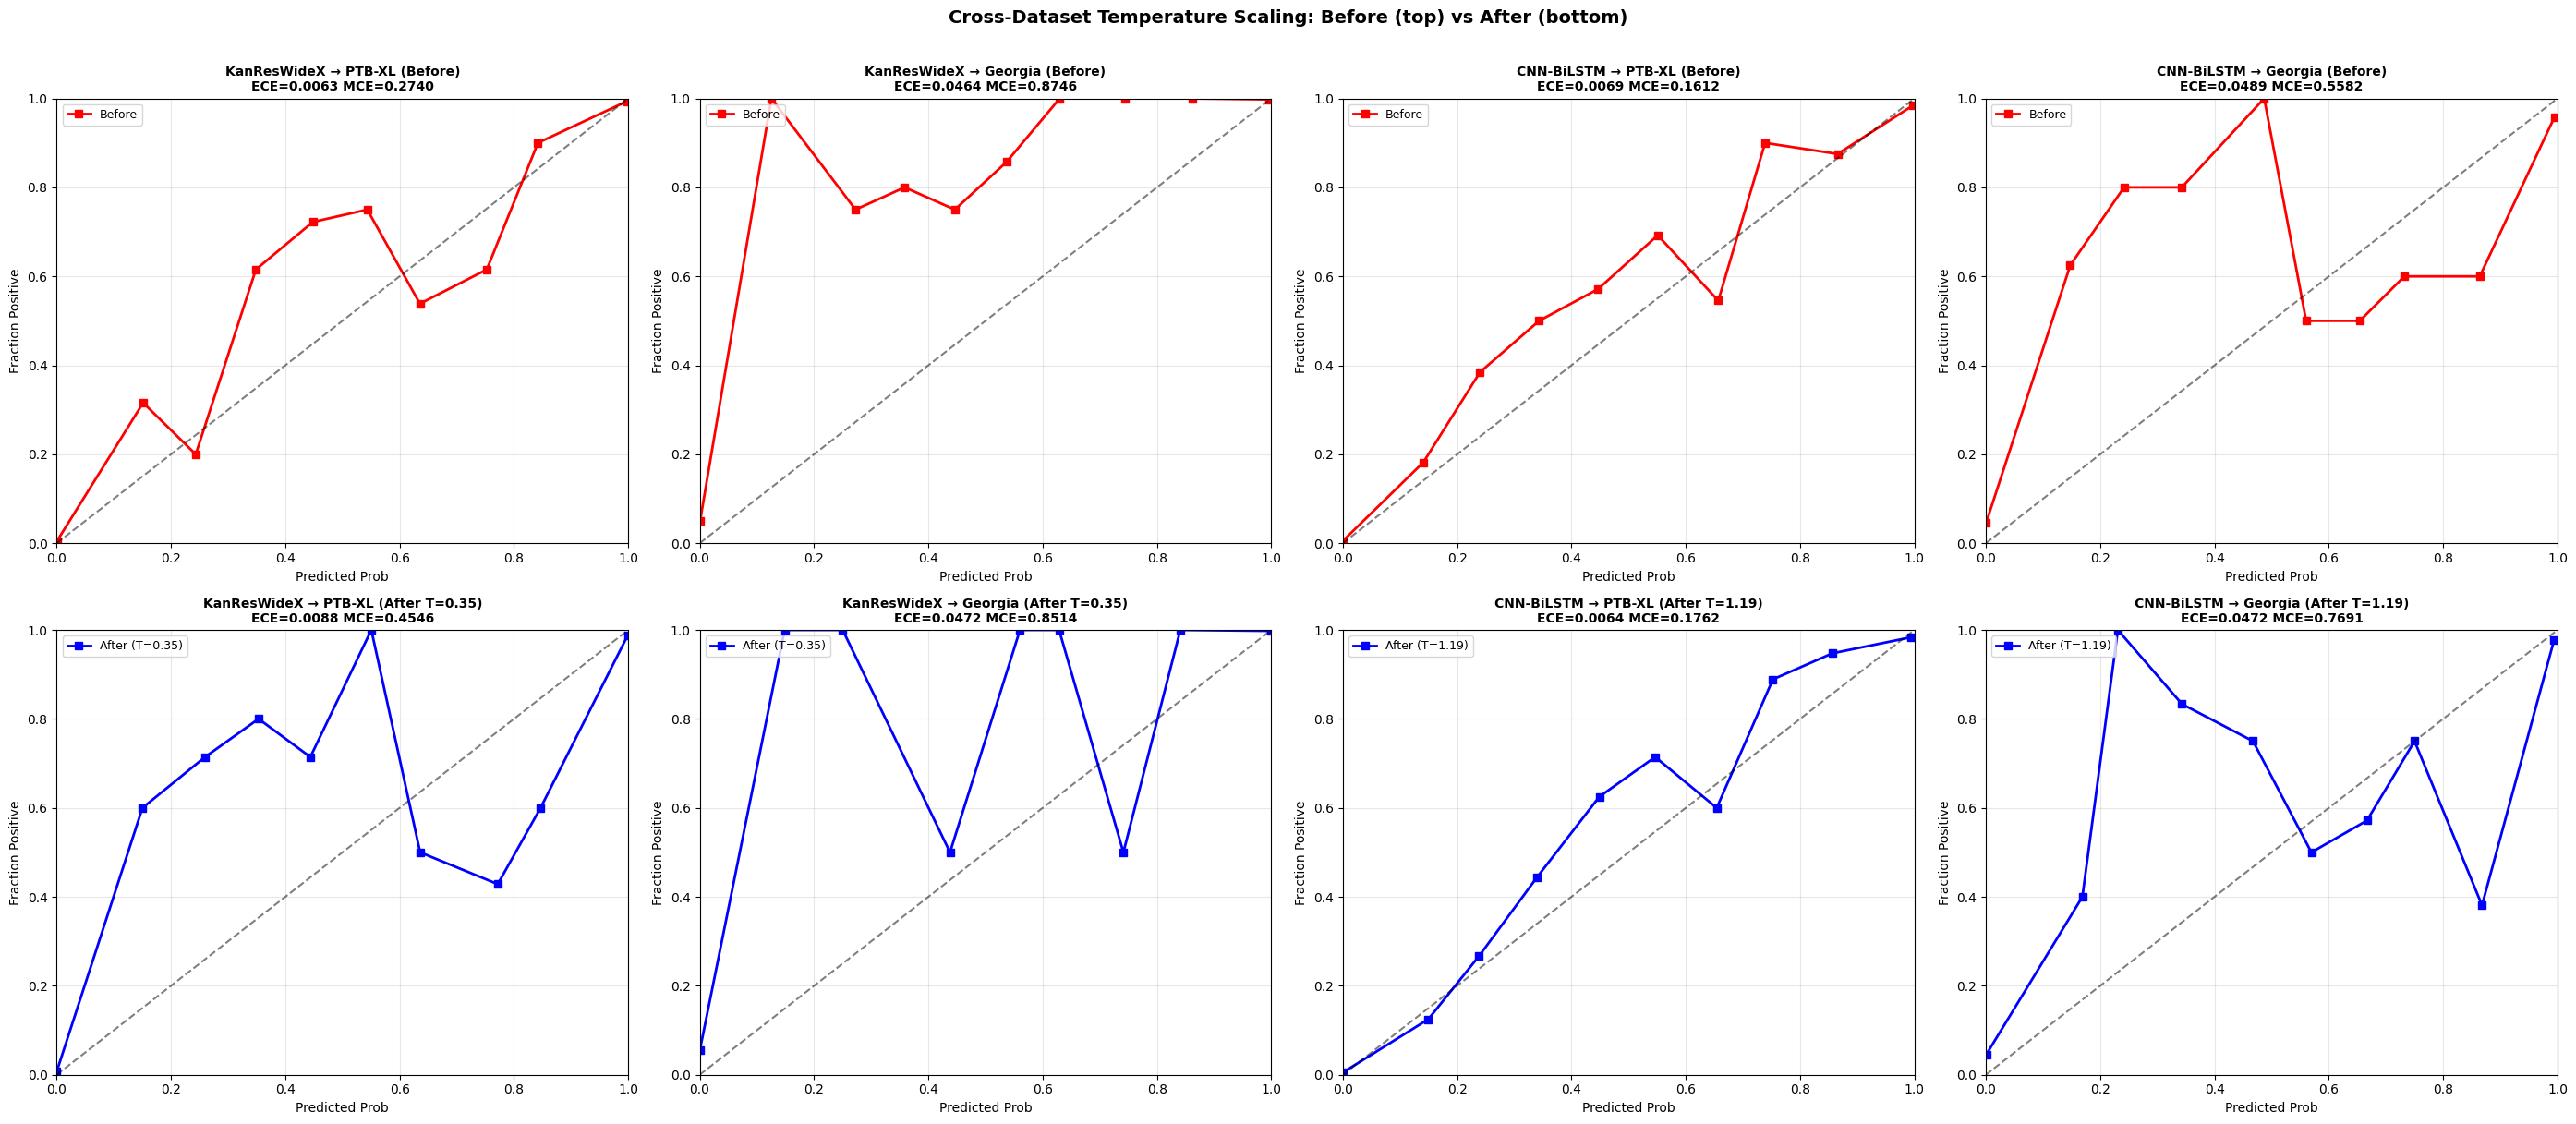

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

col = 0
for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    for ds_name in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds_name]

        # Before
        ax = axes[0][col]
        frac, mean_pred = calibration_curve(cr["targets"], cr["probs_before"], n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac, 's-', color='red', linewidth=2, markersize=6, label='Before')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        cal_b = compute_calibration_metrics(cr["targets"], cr["probs_before"])
        ax.set_title(f"{model_name} → {ds_name} (Before)\nECE={cal_b['ece']:.4f} MCE={cal_b['mce']:.4f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
        ax.legend(loc='upper left', fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)

        # After
        ax = axes[1][col]
        frac, mean_pred = calibration_curve(cr["targets"], cr["probs_after"], n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac, 's-', color='blue', linewidth=2, markersize=6, label=f'After (T={cr["T"]:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        cal_a = compute_calibration_metrics(cr["targets"], cr["probs_after"])
        ax.set_title(f"{model_name} → {ds_name} (After T={cr['T']:.2f})\nECE={cal_a['ece']:.4f} MCE={cal_a['mce']:.4f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
        ax.legend(loc='upper left', fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)

        col += 1

plt.suptitle("Cross-Dataset Temperature Scaling: Before (top) vs After (bottom)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_calibration_cross_dataset.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 16. Complete Summary Table

In [19]:
print("=" * 100)
print("COMPLETE TEMPERATURE SCALING SUMMARY")
print("=" * 100)

print(f"\n{'Model':<15} {'Dataset':<20} {'T':<8} {'ECE Before':<12} {'ECE After':<12} {'MCE Before':<12} {'MCE After':<12} {'Brier Before':<14} {'Brier After':<12}")
print("-" * 100)

for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = results[model_name]
    T = r["mean_T"]

    # Chapman-Shaoxing
    ece_b = np.mean([m["ece"] for m in r["before"]])
    ece_a = np.mean([m["ece"] for m in r["after"]])
    mce_b = np.mean([m["mce"] for m in r["before"]])
    mce_a = np.mean([m["mce"] for m in r["after"]])
    brier_b = np.mean([m["brier"] for m in r["before"]])
    brier_a = np.mean([m["brier"] for m in r["after"]])
    print(f"{model_name:<15} {'Chapman (CV)':<20} {T:<8.4f} {ece_b:<12.4f} {ece_a:<12.4f} {mce_b:<12.4f} {mce_a:<12.4f} {brier_b:<14.4f} {brier_a:<12.4f}")

    # Cross-dataset
    for ds_name in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds_name]
        print(f"{'':<15} {ds_name:<20} {cr['T']:<8.4f} {cr['before']['ece']:<12.4f} {cr['after']['ece']:<12.4f} {cr['before']['mce']:<12.4f} {cr['after']['mce']:<12.4f} {cr['before']['brier']:<14.4f} {cr['after']['brier']:<12.4f}")

print("=" * 100)

# Check accuracy preservation
print("\nAccuracy preservation (should be unchanged or minimal change):")
for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = results[model_name]
    acc_b = np.mean([m["accuracy"] for m in r["before"]])
    acc_a = np.mean([m["accuracy"] for m in r["after"]])
    print(f"  {model_name} Chapman: {acc_b:.4f} -> {acc_a:.4f}")
    for ds_name in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds_name]
        print(f"  {model_name} {ds_name}: {cr['before']['accuracy']:.4f} -> {cr['after']['accuracy']:.4f}")

COMPLETE TEMPERATURE SCALING SUMMARY

Model           Dataset              T        ECE Before   ECE After    MCE Before   MCE After    Brier Before   Brier After 
----------------------------------------------------------------------------------------------------
KanResWideX     Chapman (CV)         0.3510   0.0006       0.0004       0.1150       0.1143       0.0004         0.0004      
                PTB-XL               0.3510   0.0063       0.0088       0.2740       0.4546       0.0080         0.0088      
                Georgia              0.3510   0.0464       0.0472       0.8746       0.8514       0.0446         0.0463      
CNN-BiLSTM      Chapman (CV)         1.1862   0.0031       0.0027       0.6749       0.6493       0.0025         0.0025      
                PTB-XL               1.1862   0.0069       0.0064       0.1612       0.1762       0.0084         0.0084      
                Georgia              1.1862   0.0489       0.0472       0.5582       0.7691       0.0496 

## 17. PDF Summary

In [20]:
print(f"\nSaved PDF plots in: {config.pdf_dir}")
for f in sorted(os.listdir(config.pdf_dir)):
    if f.endswith('.pdf'):
        print(f"  {f}")


Saved PDF plots in: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_temperature_scaling
  ts_calibration_before_after_chapman.pdf
  ts_calibration_cross_dataset.pdf
  ts_prob_dist_before_after_chapman.pdf
